# R1 Journey-Based Direction Inference Test

This notebook answers one narrow question: can the `journeys_*.parquet` data assign a direction to train IDs?

It does three things:

- infer direction from journey origin and destination
- collapse the result to one row per `train_id`
- report whether each train ID is `resolved`, `conflict`, or `unresolved`


In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

In [2]:
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
JOURNEYS_DIR = DATA_DIR / "dynamic" / "journeys"
STATIONS_PATH = DATA_DIR / "static" / "stations.parquet"
TIMETABLE_DIR = PROJECT_DIR / "EDA" / "official_timetables"


def latest_file(directory: Path, pattern: str, regex_pattern: str) -> Path:
    candidates = sorted(
        path for path in directory.glob(pattern)
        if re.fullmatch(regex_pattern, path.name)
    )
    if not candidates:
        raise FileNotFoundError(f"No files matching {pattern} found in {directory}.")
    return candidates[-1]


def matching_files(directory: Path, pattern: str, regex_pattern: str) -> list[Path]:
    candidates = sorted(
        path for path in directory.glob(pattern)
        if re.fullmatch(regex_pattern, path.name)
    )
    if not candidates:
        raise FileNotFoundError(f"No files matching {pattern} found in {directory}.")
    return candidates


def normalize_station_name(name):
    if pd.isna(name):
        return np.nan
    normalized = unicodedata.normalize("NFKD", str(name))
    normalized = "".join(char for char in normalized if not unicodedata.combining(char))
    normalized = normalized.lower()
    normalized = normalized.replace("|", " ")
    normalized = normalized.replace("-", " ")
    normalized = normalized.replace(".", " ")
    normalized = re.sub(r"\bst\b", "sant", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()
    aliases = {
        "barcelona el clot": "barcelona el clot arago",
        "barcelona placa de catalunya": "barcelona placa catalunya",
    }
    return aliases.get(normalized, normalized)


def get_direction_station_orders(timetable_dir: Path):
    dir1 = pd.read_csv(timetable_dir / "R1_direction1_schedules.csv", nrows=0)
    dir2 = pd.read_csv(timetable_dir / "R1_direction2_schedules.csv", nrows=0)
    dir1_order = [col for col in dir1.columns if col != "Day_Type"]
    dir2_order = [col for col in dir2.columns if col != "Day_Type"]
    return (
        {normalize_station_name(station): idx for idx, station in enumerate(dir1_order)},
        {normalize_station_name(station): idx for idx, station in enumerate(dir2_order)},
    )

In [3]:
features_path = latest_file(PROCESSED_DIR, "features_*.csv", r"features_\d{8}_\d{6}\.csv")
journey_files = matching_files(JOURNEYS_DIR, "journeys_*.parquet", r"journeys_\d{4}_\d{2}_\d{2}\.parquet")

features_df = pd.read_csv(features_path)
features_df["train_id"] = features_df["train_id"].astype(str)
feature_train_ids = set(features_df["train_id"].dropna().unique())

stations_df = pd.read_parquet(STATIONS_PATH, columns=["station_id", "name"])
stations_df["station_id"] = stations_df["station_id"].astype(str)
station_lookup = stations_df.rename(columns={"name": "station_name"}).drop_duplicates(subset=["station_id"])
station_name_by_id = dict(zip(station_lookup["station_id"], station_lookup["station_name"]))

print(f"Latest features file: {features_path.name}")
print(f"Journey files available: {len(journey_files)}")
print(f"Feature train IDs: {len(feature_train_ids):,}")
print(f"Feature rows: {len(features_df):,}")

Latest features file: features_20260607_114933.csv
Journey files available: 78
Feature train IDs: 1,046
Feature rows: 319,981


## 1. Journey-Based Direction Rule

The rule below maps `origin_station_id` and `destination_station_id` to station names, normalizes them, and checks whether the trip moves forward in the official `direction1` order or in the official `direction2` order.

A journey is labeled:

- `direction1` if origin to destination moves forward only in the official direction 1 ordering
- `direction2` if origin to destination moves forward only in the official direction 2 ordering
- missing if the endpoints cannot be matched cleanly or do not give a unique direction


In [4]:
direction1_order, direction2_order = get_direction_station_orders(TIMETABLE_DIR)

normalized_station_by_id = {
    station_id: normalize_station_name(station_name)
    for station_id, station_name in station_name_by_id.items()
}


def infer_direction_from_ids(origin_station_id, destination_station_id):
    origin = normalized_station_by_id.get(origin_station_id)
    destination = normalized_station_by_id.get(destination_station_id)

    if pd.isna(origin) or pd.isna(destination):
        return np.nan, "missing_station_mapping"
    if origin not in direction1_order or destination not in direction1_order:
        return np.nan, "not_in_official_orders"

    dir1_delta = direction1_order[destination] - direction1_order[origin]
    dir2_delta = direction2_order[destination] - direction2_order[origin]

    if dir1_delta > 0 and dir2_delta < 0:
        return "direction1", "resolved"
    if dir2_delta > 0 and dir1_delta < 0:
        return "direction2", "resolved"
    if dir1_delta == 0 or dir2_delta == 0:
        return np.nan, "same_origin_destination_order"
    return np.nan, "ambiguous_endpoint_order"


pair_result_cache = {}
train_direction_sets = {train_id: set() for train_id in feature_train_ids}
train_status_counts = {train_id: {} for train_id in feature_train_ids}
train_journey_rows = {train_id: 0 for train_id in feature_train_ids}
sample_rows = []

for path in journey_files:
    chunk = pd.read_parquet(
        path,
        columns=["journey_id", "train_id", "origin_station_id", "destination_station_id"],
    )
    chunk["train_id"] = chunk["train_id"].astype(str)
    chunk = chunk[chunk["train_id"].isin(feature_train_ids)].copy()
    if chunk.empty:
        continue

    chunk["origin_station_id"] = chunk["origin_station_id"].astype(str)
    chunk["destination_station_id"] = chunk["destination_station_id"].astype(str)

    sample_chunk = chunk.head(max(0, 10 - len(sample_rows))).copy()
    sample_chunk["origin_station_name"] = sample_chunk["origin_station_id"].map(station_name_by_id)
    sample_chunk["destination_station_name"] = sample_chunk["destination_station_id"].map(station_name_by_id)

    grouped = (
        chunk.groupby(["train_id", "origin_station_id", "destination_station_id"], as_index=False)
        .size()
        .rename(columns={"size": "row_count"})
    )

    grouped["pair_key"] = list(zip(grouped["origin_station_id"], grouped["destination_station_id"]))

    uncached_keys = [key for key in grouped["pair_key"].unique().tolist() if key not in pair_result_cache]
    for origin_station_id, destination_station_id in uncached_keys:
        pair_result_cache[(origin_station_id, destination_station_id)] = infer_direction_from_ids(origin_station_id, destination_station_id)

    grouped["journey_direction"] = grouped["pair_key"].map(lambda key: pair_result_cache[key][0])
    grouped["journey_direction_status"] = grouped["pair_key"].map(lambda key: pair_result_cache[key][1])

    for row in grouped.itertuples(index=False):
        train_journey_rows[row.train_id] += row.row_count
        train_status_counts[row.train_id][row.journey_direction_status] = train_status_counts[row.train_id].get(row.journey_direction_status, 0) + row.row_count
        if pd.notna(row.journey_direction):
            train_direction_sets[row.train_id].add(row.journey_direction)

    for row in sample_chunk.itertuples(index=False):
        direction, status = pair_result_cache[(row.origin_station_id, row.destination_station_id)]
        sample_rows.append({
            "journey_id": row.journey_id,
            "train_id": row.train_id,
            "origin_station_name": row.origin_station_name,
            "destination_station_name": row.destination_station_name,
            "journey_direction": direction,
            "journey_direction_status": status,
        })

sample_rows_df = pd.DataFrame(sample_rows)
print(f"Journey rows processed for relevant train IDs: {sum(train_journey_rows.values()):,}")
print(f"Unique origin/destination pairs evaluated: {len(pair_result_cache):,}")
display(sample_rows_df)

Journey rows processed for relevant train IDs: 11,134,859
Unique origin/destination pairs evaluated: 3,114


,journey_id,train_id,origin_station_name,destination_station_name,journey_direction,journey_direction_status
0,77432_72302_78700_2026-03-15 14:19:00,77432,Sant Joan Despí,Terrassa Estació del Nord,NaN,not_in_official_orders
1,77434_72302_78700_2026-03-15 14:32:00,77434,Sant Joan Despí,Terrassa Estació del Nord,NaN,not_in_official_orders
2,77436_72302_78700_2026-03-15 15:15:00,77436,Sant Joan Despí,Terrassa Estació del Nord,NaN,not_in_official_orders
3,77438_72302_78700_2026-03-15 15:45:00,77438,Sant Joan Despí,Terrassa Estació del Nord,NaN,not_in_official_orders
4,25644_79009_72305_2026-03-15 14:22:00,25644,Barcelona-El Clot,L'Hospitalet de Llobregat,direction2,resolved
5,25740_79009_72305_2026-03-15 14:27:00,25740,Barcelona-El Clot,L'Hospitalet de Llobregat,direction2,resolved
6,25820_79009_72305_2026-03-15 14:37:00,25820,Barcelona-El Clot,L'Hospitalet de Llobregat,direction2,resolved
7,25646_79009_72305_2026-03-15 14:44:00,25646,Barcelona-El Clot,L'Hospitalet de Llobregat,direction2,resolved
8,28438_79009_72305_2026-03-15 14:56:00,28438,Barcelona-El Clot,L'Hospitalet de Llobregat,direction2,resolved
9,15862_79009_72305_2026-03-15 15:00:00,15862,Barcelona-El Clot,L'Hospitalet de Llobregat,direction2,resolved


## 2. Collapse to One Direction per Train

Because a train can appear in multiple journey rows, this step checks whether all journey-based labels for a given `train_id` agree.

A train is:

- `resolved` if at least one journey row resolves and all resolved rows agree
- `conflict` if the same train receives both directions across journey rows
- `unresolved` if no journey row resolves a direction


In [5]:
train_journey_summary = pd.DataFrame({
    "train_id": sorted(feature_train_ids),
    "journey_rows": [train_journey_rows[train_id] for train_id in sorted(feature_train_ids)],
    "resolved_rows": [
        train_status_counts[train_id].get("resolved", 0)
        for train_id in sorted(feature_train_ids)
    ],
    "unique_resolved_directions": [
        sorted(train_direction_sets[train_id])
        for train_id in sorted(feature_train_ids)
    ],
    "top_unresolved_reason": [
        max(train_status_counts[train_id], key=train_status_counts[train_id].get) if train_status_counts[train_id] else np.nan
        for train_id in sorted(feature_train_ids)
    ],
})


def collapse_train_direction(row):
    values = row["unique_resolved_directions"]
    if row["journey_rows"] == 0:
        return pd.Series([np.nan, "journey_not_found"])
    if len(values) == 1:
        return pd.Series([values[0], "resolved"])
    if len(values) > 1:
        return pd.Series([np.nan, "conflict"])
    return pd.Series([np.nan, "unresolved"])


train_journey_summary[["journey_train_direction", "journey_train_status"]] = train_journey_summary.apply(
    collapse_train_direction,
    axis=1,
)

display(train_journey_summary.head(10))

,train_id,journey_rows,resolved_rows,unique_resolved_directions,top_unresolved_reason,journey_train_direction,journey_train_status
0,15700,472,137,[direction1],not_in_official_orders,direction1,resolved
1,15702,541,159,[direction1],not_in_official_orders,direction1,resolved
2,15710,131,30,[direction2],not_in_official_orders,direction2,resolved
3,15720,323,88,[direction1],not_in_official_orders,direction1,resolved
4,15722,309,89,[direction1],not_in_official_orders,direction1,resolved
5,15726,564,167,[direction1],not_in_official_orders,direction1,resolved
6,15728,357,106,[direction1],not_in_official_orders,direction1,resolved
7,15730,200,58,[direction1],not_in_official_orders,direction1,resolved
8,15734,356,106,[direction1],not_in_official_orders,direction1,resolved
9,15736,205,61,[direction1],not_in_official_orders,direction1,resolved


## 3. Train-ID Resolution Table

This section reduces the result to one row per `train_id` from the latest features table.

The `status` column means:

- `resolved`: at least one journey row exists for the train and all resolved journey rows agree on direction
- `conflict`: journey rows exist for the train but imply both directions
- `unresolved`: the train appears in journeys but no row gives a unique direction
- `journey_not_found`: the train ID from the latest features file does not appear in the journeys parquet history loaded here


In [6]:
feature_trains = (
    features_df.groupby("train_id", dropna=False)
    .agg(feature_rows=("train_id", "size"))
    .reset_index()
)

train_direction_table = feature_trains.merge(
    train_journey_summary[["train_id", "journey_rows", "resolved_rows", "journey_train_direction", "journey_train_status"]],
    on="train_id",
    how="left",
)

train_direction_table["journey_found"] = train_direction_table["journey_rows"].notna()
train_direction_table["status"] = train_direction_table["journey_train_status"].fillna("journey_not_found")
train_direction_table = train_direction_table.rename(columns={"journey_train_direction": "journey_direction"})

display(train_direction_table.head(20))

,train_id,feature_rows,journey_rows,resolved_rows,journey_direction,journey_train_status,journey_found,status
0,15700,119,472,137,direction1,resolved,True,resolved
1,15702,142,541,159,direction1,resolved,True,resolved
2,15710,21,131,30,direction2,resolved,True,resolved
3,15720,91,323,88,direction1,resolved,True,resolved
4,15722,91,309,89,direction1,resolved,True,resolved
5,15726,138,564,167,direction1,resolved,True,resolved
6,15728,91,357,106,direction1,resolved,True,resolved
7,15730,49,200,58,direction1,resolved,True,resolved
8,15734,95,356,106,direction1,resolved,True,resolved
9,15736,49,205,61,direction1,resolved,True,resolved


In [7]:
summary = (
    train_direction_table["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="train_count")
)
summary["pct_of_feature_trains"] = 100 * summary["train_count"] / len(train_direction_table)

display(summary)

,status,train_count,pct_of_feature_trains
0,resolved,682,65.200765
1,unresolved,294,28.107075
2,journey_not_found,70,6.692161


/tmp/ipykernel_21501/2340444036.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="status", y="train_count", palette="Set2")


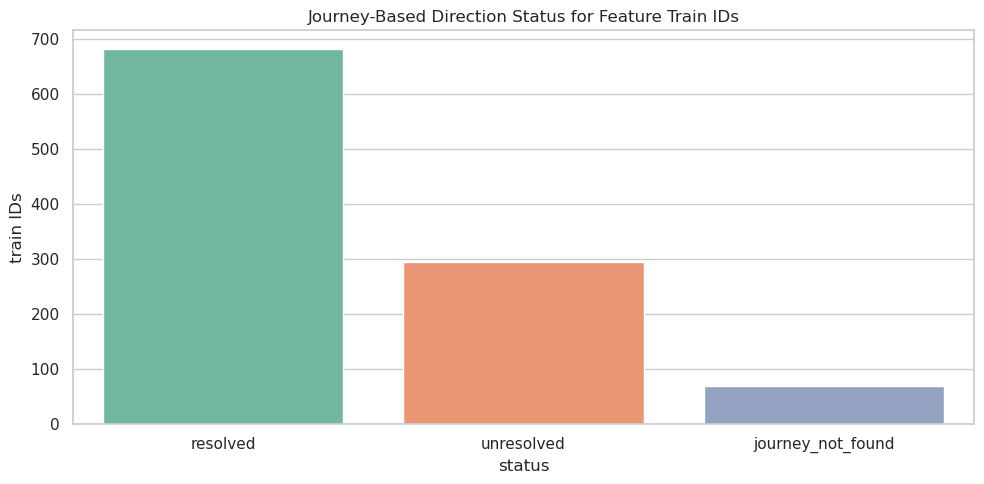

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x="status", y="train_count", palette="Set2")
plt.title("Journey-Based Direction Status for Feature Train IDs")
plt.ylabel("train IDs")
plt.xlabel("status")
plt.tight_layout()
plt.show()

## 4. Inspect the Resulting Train-ID Table

These tables are the practical output of the notebook:

- train IDs resolved by journeys
- train IDs with conflicting journey evidence
- train IDs that appear in features but were not found in journeys or remain unresolved


In [9]:
resolved_trains = train_direction_table[train_direction_table["status"] == "resolved"].copy()
conflict_trains = train_direction_table[train_direction_table["status"] == "conflict"].copy()
missing_or_unresolved_trains = train_direction_table[
    train_direction_table["status"].isin(["journey_not_found", "unresolved"])
].copy()

print("Resolved train IDs:")
display(resolved_trains.head(20))
print(resolved_trains["status"].value_counts())

print("Conflicting train IDs:")
display(conflict_trains.head(20))

print("Journey not found or unresolved:")
display(missing_or_unresolved_trains.head(20))
print(missing_or_unresolved_trains["status"].value_counts())

Resolved train IDs:


,train_id,feature_rows,journey_rows,resolved_rows,journey_direction,journey_train_status,journey_found,status
0,15700,119,472,137,direction1,resolved,True,resolved
1,15702,142,541,159,direction1,resolved,True,resolved
2,15710,21,131,30,direction2,resolved,True,resolved
3,15720,91,323,88,direction1,resolved,True,resolved
4,15722,91,309,89,direction1,resolved,True,resolved
5,15726,138,564,167,direction1,resolved,True,resolved
6,15728,91,357,106,direction1,resolved,True,resolved
7,15730,49,200,58,direction1,resolved,True,resolved
8,15734,95,356,106,direction1,resolved,True,resolved
9,15736,49,205,61,direction1,resolved,True,resolved


status
resolved    682
Name: count, dtype: int64
Conflicting train IDs:


,train_id,feature_rows,journey_rows,resolved_rows,journey_direction,journey_train_status,journey_found,status


Journey not found or unresolved:


,train_id,feature_rows,journey_rows,resolved_rows,journey_direction,journey_train_status,journey_found,status
99,25478,19,2686,0,NaN,unresolved,True,unresolved
100,25480,7,1012,0,NaN,unresolved,True,unresolved
101,25482,6,1035,0,NaN,unresolved,True,unresolved
102,25484,48,2431,0,NaN,unresolved,True,unresolved
103,25486,7,554,0,NaN,unresolved,True,unresolved
105,25490,48,2561,0,NaN,unresolved,True,unresolved
106,25500,13,1178,0,NaN,unresolved,True,unresolved
107,25501,21,1995,0,NaN,unresolved,True,unresolved
108,25502,20,3688,0,NaN,unresolved,True,unresolved
109,25503,20,2042,0,NaN,unresolved,True,unresolved


status
unresolved           294
journey_not_found     70
Name: count, dtype: int64


## 5. Interpretation Guide

Use the results with this logic:

- if many train IDs are `resolved`, then journeys can serve as a usable train-level direction source
- if many train IDs are `journey_not_found`, the limiting factor is coverage, not inference logic
- if many train IDs are `conflict`, the journey data is not stable enough to use without stricter filtering
- if many train IDs are `unresolved`, the endpoints often do not map cleanly to a unique official R1 direction
